<h1 align="center" id="top"><u>RL project</u></h1>
<h3 align="center"><u>Clément MOLLY-MITTON | Diane VERBECQ | Fanny BADOULES | Ghiles KEMICHE</u></h3>

# Table of Contents
***
1. [Import](#import)
2. [Testing](#testing)

## Import
***

In [1]:
from pathlib import Path

from rl_project.benchmark.benchmark import HighwayBenchmark
from rl_project.benchmark.typing import BenchmarkConfig
from rl_project.models.core.typing import ModelType
from rl_project.models.factory import load_model
from scripts.envs.factory import get_env_config
from scripts.envs.typing import EnvType
from scripts.utils.cache import CacheManager
from scripts.utils.display import display_episode

## Testing
***

In [14]:
env_type = EnvType.BASELINE
env_id, env_config = get_env_config(env_type)
env_config["offscreen_rendering"] = True

benchmark = HighwayBenchmark(
    config=BenchmarkConfig(
        env_id=env_id,
        env_config=env_config,
    ),
    render_mode="rgb_array",
)
seed = 1
env = benchmark.make_env(seed=seed)

model_type = ModelType.DQN
model_path = (
    Path.cwd().parents[2]
    / "data"
    / "training"
    / model_type.value
    / env_type.value
    / f"seed_{seed}"
    / f"model_{model_type.value}_{env_type.value}_seed_{seed}_final.pt"
)
model = load_model(model_type, model_path)

stats = display_episode(
    env=env,
    model=model,
    greedy=True,
    sleep_time=0.03,
)
stats

FileNotFoundError: Model file not found: c:\Bureau\CS\partie3\RL\RL-project\data\training\dqn\baseline\seed_1\model_dqn_baseline_seed_1_final.pt

In [2]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Project root not found from current working directory")


def build_dataframe_name(csv_path: Path, data_dir: Path) -> str:
    relative_parts = csv_path.relative_to(data_dir).with_suffix("").parts
    sanitized_parts = [part.replace("-", "_") for part in relative_parts]
    return "_".join(sanitized_parts) + "_df"


project_root = find_project_root(Path.cwd())
data_dir = project_root / "data"

loaded_dataframes = {}

for csv_path in sorted(data_dir.rglob("*.csv")):
    dataframe_name = build_dataframe_name(csv_path, data_dir)
    dataframe = CacheManager.load(csv_path)
    loaded_dataframes[dataframe_name] = dataframe
    globals()[dataframe_name] = dataframe

len(sorted(loaded_dataframes))

32

## Training curves
***

,model,config,seed,mean_reward,mean_episode_length,crash_rate,offroad_rate,mean_speed
0,DQN,Baseline,0,13.636237,18.711019,0.609148,0.0,23.377425
1,DQN,Baseline,1,13.636237,18.711019,0.609148,0.0,23.377425
8,SB3,Baseline,0,11.580547,15.526667,0.790000,0.0,24.060789
9,SB3,Baseline,1,13.636237,18.711019,0.609148,0.0,23.377425
2,DQN,Dense,0,11.580547,15.526667,0.790000,0.0,24.060789
3,DQN,Dense,1,13.636237,18.711019,0.609148,0.0,23.377425
10,SB3,Dense,0,11.580547,15.526667,0.790000,0.0,24.060789
11,SB3,Dense,1,13.636237,18.711019,0.609148,0.0,23.377425
4,DQN,Greedy,0,11.580547,15.526667,0.790000,0.0,24.060789
5,DQN,Greedy,1,13.636237,18.711019,0.609148,0.0,23.377425


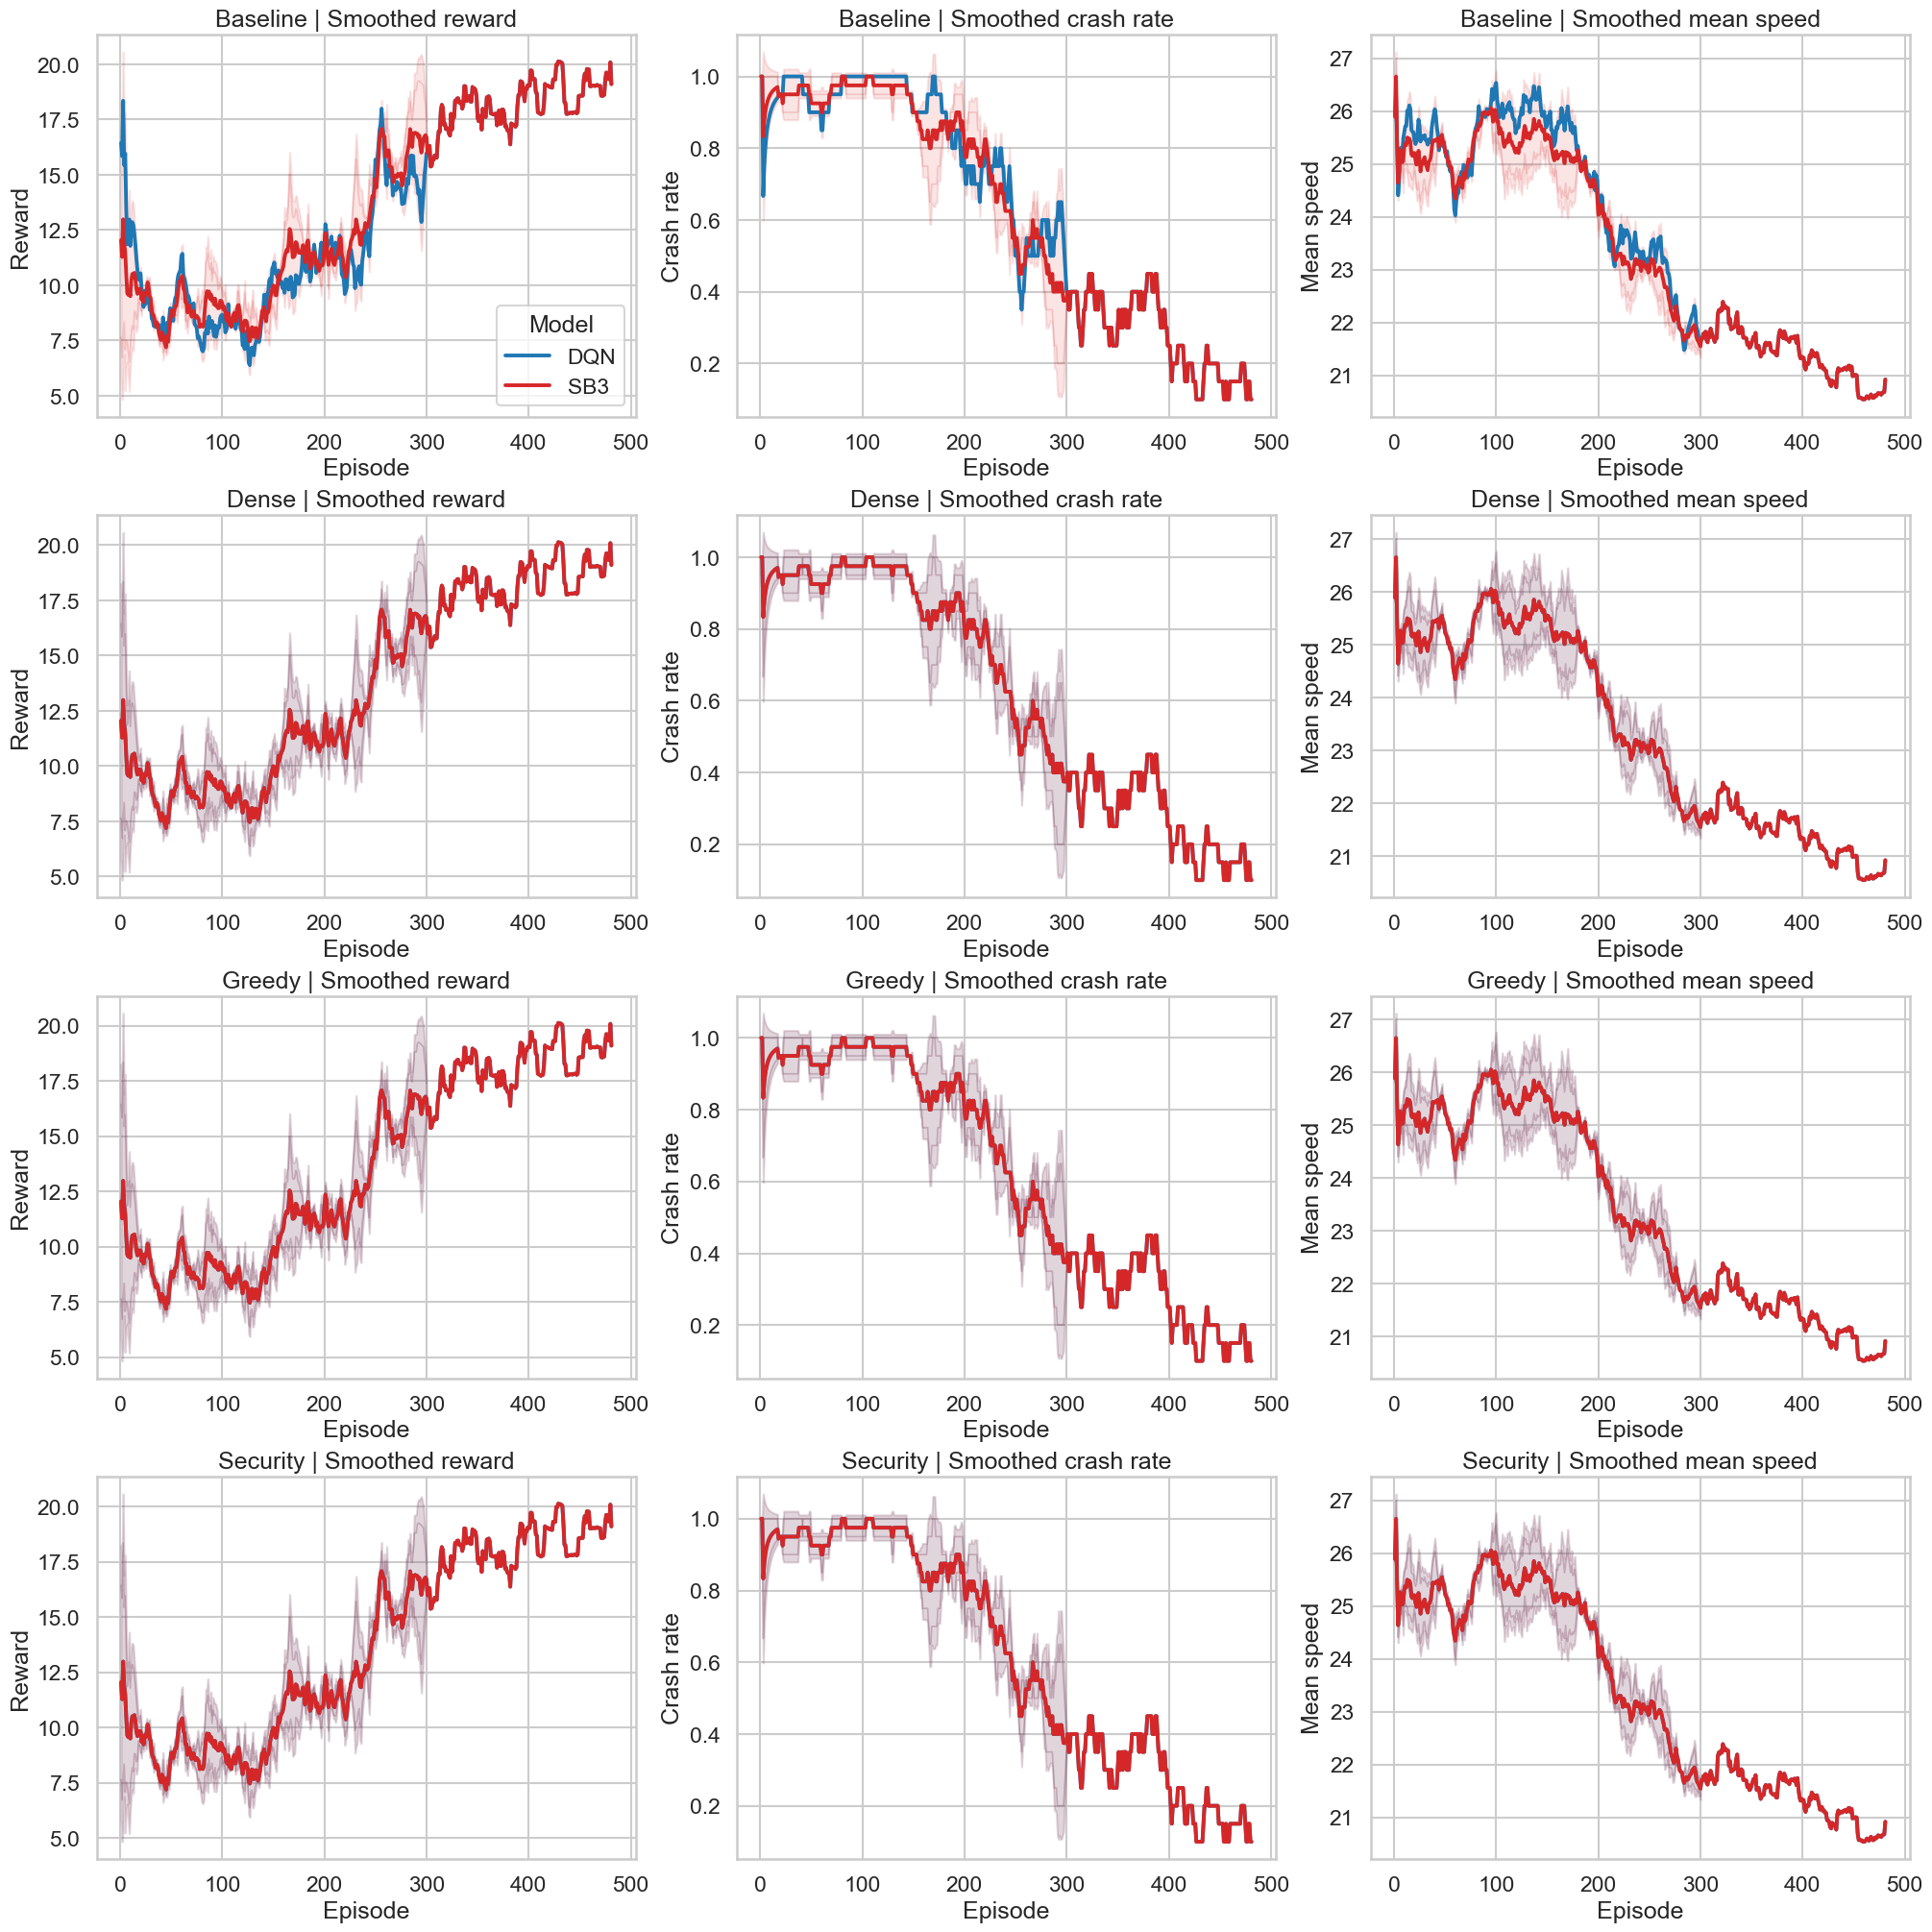

,model,config,final_reward_mean,final_reward_std,final_crash_rate,final_offroad_rate,final_mean_speed
0,DQN,Baseline,18.462910,5.403440,0.163265,0.0,20.863726
4,SB3,Baseline,18.272702,5.626195,0.215190,0.0,21.135255
1,DQN,Dense,18.272702,5.626195,0.215190,0.0,21.135255
5,SB3,Dense,18.272702,5.626195,0.215190,0.0,21.135255
2,DQN,Greedy,18.272702,5.626195,0.215190,0.0,21.135255
6,SB3,Greedy,18.272702,5.626195,0.215190,0.0,21.135255
3,DQN,Security,18.272702,5.626195,0.215190,0.0,21.135255
7,SB3,Security,18.272702,5.626195,0.215190,0.0,21.135255


In [ ]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

TRAINING_KEY_PATTERN = re.compile(
    r"^training_(?P<model>[^_]+)_(?P<config>[^_]+)_seed_(?P<seed>\d+)_.*_df$"
)


def to_episode_history(df: pd.DataFrame) -> pd.DataFrame:
    frame = df.copy()

    if "step" in frame.columns and "episode" in frame.columns:
        episode_history = (
            frame.groupby("episode", as_index=False)
            .agg(
                reward=("reward", "sum"),
                length=("step_in_episode", "max"),
                crashed=("crashed", "max"),
                offroad=("offroad", "max"),
                mean_speed=("speed", "mean"),
                total_steps=("step", "max"),
            )
            .sort_values("episode")
            .reset_index(drop=True)
        )
        episode_history["episode"] = episode_history["episode"] + 1
        episode_history["length"] = episode_history["length"] + 1
        episode_history["total_steps"] = episode_history["total_steps"] + 1
    elif {"episode", "reward", "length"}.issubset(frame.columns):
        episode_history = frame.sort_values("episode").reset_index(drop=True).copy()
    else:
        raise ValueError(f"Unsupported training history schema: {frame.columns.tolist()}")

    for column in ["crashed", "offroad"]:
        if column in episode_history.columns:
            episode_history[column] = episode_history[column].astype(float)

    return episode_history


training_runs = []

for dataframe_name, df in loaded_dataframes.items():
    match = TRAINING_KEY_PATTERN.match(dataframe_name)
    if match is None:
        continue

    metadata = match.groupdict()
    episode_history = to_episode_history(df)
    episode_history["model"] = metadata["model"].upper()
    episode_history["config"] = metadata["config"].capitalize()
    episode_history["seed"] = int(metadata["seed"])
    training_runs.append(episode_history)

training_history = pd.concat(training_runs, ignore_index=True)

rolling_window = 20
for source_col, smooth_col in [
    ("reward", "reward_smooth"),
    ("crashed", "crash_rate_smooth"),
    ("offroad", "offroad_rate_smooth"),
    ("mean_speed", "mean_speed_smooth"),
]:
    training_history[smooth_col] = training_history.groupby(["model", "config", "seed"])[
        source_col
    ].transform(lambda s: s.rolling(window=min(rolling_window, len(s)), min_periods=1).mean())

training_summary = (
    training_history.groupby(["model", "config", "seed"], as_index=False)
    .agg(
        mean_reward=("reward", "mean"),
        mean_episode_length=("length", "mean"),
        crash_rate=("crashed", "mean"),
        offroad_rate=("offroad", "mean"),
        mean_speed=("mean_speed", "mean"),
    )
    .sort_values(["config", "model", "seed"])
)

display(training_summary)

plot_data = (
    training_history.groupby(["config", "model", "episode"], as_index=False)
    .agg(
        reward_mean=("reward_smooth", "mean"),
        reward_std=("reward_smooth", "std"),
        crash_mean=("crash_rate_smooth", "mean"),
        crash_std=("crash_rate_smooth", "std"),
        speed_mean=("mean_speed_smooth", "mean"),
        speed_std=("mean_speed_smooth", "std"),
    )
    .fillna(0.0)
)

configs = sorted(training_history["config"].unique())
palette = {"DQN": "#1f77b4", "SB3": "#d62728"}
plot_specs = [
    ("reward", "Smoothed reward", "Reward"),
    ("crash", "Smoothed crash rate", "Crash rate"),
    ("speed", "Smoothed mean speed", "Mean speed"),
]

fig, axes = plt.subplots(
    nrows=len(configs),
    ncols=len(plot_specs),
    figsize=(20, 5 * len(configs)),
    sharex=False,
    constrained_layout=True,
)

if len(configs) == 1:
    axes = np.array([axes])

for row_idx, config in enumerate(configs):
    config_seed_data = training_history[training_history["config"] == config]
    config_mean_data = plot_data[plot_data["config"] == config]

    for col_idx, (metric_prefix, title, ylabel) in enumerate(plot_specs):
        ax = axes[row_idx, col_idx]
        mean_col = f"{metric_prefix}_mean"
        std_col = f"{metric_prefix}_std"
        smooth_col = {
            "reward": "reward_smooth",
            "crash": "crash_rate_smooth",
            "speed": "mean_speed_smooth",
        }[metric_prefix]

        for (model, seed), seed_df in config_seed_data.groupby(["model", "seed"]):
            ax.plot(
                seed_df["episode"],
                seed_df[smooth_col],
                color=palette[model],
                alpha=0.18,
                linewidth=1.2,
            )

        for model, model_df in config_mean_data.groupby("model"):
            model_df = model_df.sort_values("episode")
            ax.plot(
                model_df["episode"],
                model_df[mean_col],
                color=palette[model],
                linewidth=2.8,
                label=model,
            )
            ax.fill_between(
                model_df["episode"],
                model_df[mean_col] - model_df[std_col],
                model_df[mean_col] + model_df[std_col],
                color=palette[model],
                alpha=0.12,
            )

        ax.set_title(f"{config} | {title}")
        ax.set_xlabel("Episode")
        ax.set_ylabel(ylabel)
        if row_idx == 0 and col_idx == 0:
            ax.legend(title="Model")
        else:
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()

plt.show()

final_fraction = 0.1
late_training = training_history.sort_values(["model", "config", "seed", "episode"]).copy()
late_training["episodes_in_run"] = late_training.groupby(["model", "config", "seed"])[
    "episode"
].transform("size")
late_training["episodes_from_end"] = late_training.groupby(["model", "config", "seed"])[
    "episode"
].transform(lambda s: s.max() - s + 1)
late_training = late_training[
    late_training["episodes_from_end"]
    <= np.maximum(10, np.ceil(late_training["episodes_in_run"] * final_fraction))
].copy()

late_training_summary = (
    late_training.groupby(["model", "config"], as_index=False)
    .agg(
        final_reward_mean=("reward", "mean"),
        final_reward_std=("reward", "std"),
        final_crash_rate=("crashed", "mean"),
        final_offroad_rate=("offroad", "mean"),
        final_mean_speed=("mean_speed", "mean"),
    )
    .sort_values(["config", "model"])
)

display(late_training_summary)


## comparison between your DQN and the Stable-Baselines model using the same config, same evaluation seeds, and same metrics
***

In [ ]:
import re

import numpy as np
import pandas as pd

summary_pattern = re.compile(
    r"data[\\/]evaluation[\\/](?P<model>[^\\/]+)[\\/](?P<config>[^\\/]+)[\\/]seed_(?P<train_seed>\d+)[\\/]evaluation_summary\.json$"
)

summary_records = []
for summary_path in sorted((data_dir / "evaluation").rglob("evaluation_summary.json")):
    match = summary_pattern.search(str(summary_path))
    if match is None:
        continue

    metadata = match.groupdict()
    summary = CacheManager.load(summary_path)
    summary_records.append(
        {
            "model": metadata["model"].upper(),
            "config": metadata["config"].capitalize(),
            "train_seed": int(metadata["train_seed"]),
            **summary,
        }
    )

if not summary_records:
    raise ValueError("No evaluation_summary.json files found under data/evaluation")

evaluation_summary_df = pd.DataFrame(summary_records).sort_values(["config", "model", "train_seed"])

display(evaluation_summary_df.round(3))

common_summary_pairs = (
    evaluation_summary_df.groupby(["config", "train_seed"])["model"]
    .nunique()
    .reset_index(name="n_models")
    .query("n_models == 2")[["config", "train_seed"]]
)

paired_summary_df = evaluation_summary_df.merge(
    common_summary_pairs,
    on=["config", "train_seed"],
    how="inner",
)

paired_inventory = (
    paired_summary_df.groupby(["config", "model"], as_index=False)
    .agg(
        n_training_seeds=("train_seed", "nunique"),
        train_seeds=("train_seed", lambda s: sorted(int(v) for v in s)),
        n_episodes_values=("n_episodes", lambda s: sorted(int(v) for v in set(s))),
    )
    .sort_values(["config", "model"])
)

summary_table = (
    paired_summary_df.groupby(["config", "model"], as_index=False)
    .agg(
        n_training_seeds=("train_seed", "nunique"),
        reward_mean=("mean_reward", "mean"),
        reward_std_across_seeds=("mean_reward", "std"),
        mean_internal_std_reward=("std_reward", "mean"),
        episode_length_mean=("mean_episode_length", "mean"),
        crash_rate_mean=("crash_rate", "mean"),
        offroad_rate_mean=("offroad_rate", "mean"),
        mean_speed_mean=("mean_speed", "mean"),
        n_episodes=("n_episodes", "mean"),
    )
    .sort_values(["config", "model"])
    .fillna(0.0)
)

paired_summary_comparison = paired_summary_df.pivot_table(
    index=["config", "train_seed"],
    columns="model",
    values=[
        "mean_reward",
        "std_reward",
        "mean_episode_length",
        "crash_rate",
        "offroad_rate",
        "mean_speed",
        "n_episodes",
    ],
)
paired_summary_comparison.columns = [
    f"{metric}_{model}" for metric, model in paired_summary_comparison.columns
]
paired_summary_comparison = paired_summary_comparison.reset_index()

for metric in [
    "mean_reward",
    "std_reward",
    "mean_episode_length",
    "crash_rate",
    "offroad_rate",
    "mean_speed",
]:
    paired_summary_comparison[f"delta_{metric}_dqn_minus_sb3"] = (
        paired_summary_comparison[f"{metric}_DQN"] - paired_summary_comparison[f"{metric}_SB3"]
    )

comparison_table_json = (
    paired_summary_comparison.groupby("config", as_index=False)
    .agg(
        paired_training_seeds=("train_seed", "nunique"),
        reward_delta_mean=("delta_mean_reward_dqn_minus_sb3", "mean"),
        reward_delta_std=("delta_mean_reward_dqn_minus_sb3", "std"),
        std_reward_delta_mean=("delta_std_reward_dqn_minus_sb3", "mean"),
        episode_length_delta_mean=("delta_mean_episode_length_dqn_minus_sb3", "mean"),
        crash_rate_delta_mean=("delta_crash_rate_dqn_minus_sb3", "mean"),
        offroad_rate_delta_mean=("delta_offroad_rate_dqn_minus_sb3", "mean"),
        mean_speed_delta_mean=("delta_mean_speed_dqn_minus_sb3", "mean"),
        n_episodes_dqn=("n_episodes_DQN", "mean"),
        n_episodes_sb3=("n_episodes_SB3", "mean"),
    )
    .sort_values("config")
    .fillna(0.0)
)

comparison_table_json["better_model_on_reward"] = np.where(
    comparison_table_json["reward_delta_mean"] > 0,
    "DQN",
    np.where(comparison_table_json["reward_delta_mean"] < 0, "SB3", "Tie"),
)
comparison_table_json["better_model_on_safety"] = np.where(
    comparison_table_json["crash_rate_delta_mean"] < 0,
    "DQN",
    np.where(comparison_table_json["crash_rate_delta_mean"] > 0, "SB3", "Tie"),
)
comparison_table_json["episode_budget_check"] = np.where(
    (comparison_table_json["n_episodes_dqn"] == 50)
    & (comparison_table_json["n_episodes_sb3"] == 50),
    "OK: 50 episodes",
    "Provisional: not 50 episodes yet",
)

print(
    "Paired evaluation inventory: common configs and training seeds available for both DQN and SB3."
)
display(paired_inventory)

print("Evaluation summary table aggregated from evaluation_summary.json.")
display(summary_table.round(3))

print("Final DQN vs SB3 comparison based on the aggregated evaluation summaries.")
display(comparison_table_json.round(3))


,model,config,train_seed,mean_reward,std_reward,mean_episode_length,crash_rate,offroad_rate,mean_speed,n_episodes
0,DQN,Baseline,0,16.582,6.531,22.9,0.4,0.0,22.313,10
5,SB3,Baseline,0,16.582,6.531,22.9,0.4,0.0,22.313,10
1,DQN,Dense,0,16.582,6.531,22.9,0.4,0.0,22.313,10
2,DQN,Dense,1,16.582,6.531,22.9,0.4,0.0,22.313,10
6,SB3,Dense,0,16.582,6.531,22.9,0.4,0.0,22.313,10
7,SB3,Dense,1,16.582,6.531,22.9,0.4,0.0,22.313,10
3,DQN,Greedy,0,16.582,6.531,22.9,0.4,0.0,22.313,10
8,SB3,Greedy,0,16.582,6.531,22.9,0.4,0.0,22.313,10
4,DQN,Security,0,16.582,6.531,22.9,0.4,0.0,22.313,10
9,SB3,Security,0,16.582,6.531,22.9,0.4,0.0,22.313,10


Paired evaluation inventory: common configs and training seeds available for both DQN and SB3.


,config,model,n_training_seeds,train_seeds,n_episodes_values
0,Baseline,DQN,1,[0],[10]
1,Baseline,SB3,1,[0],[10]
2,Dense,DQN,2,"[0, 1]",[10]
3,Dense,SB3,2,"[0, 1]",[10]
4,Greedy,DQN,1,[0],[10]
5,Greedy,SB3,1,[0],[10]
6,Security,DQN,1,[0],[10]
7,Security,SB3,1,[0],[10]


Evaluation summary table aggregated from evaluation_summary.json.


,config,model,n_training_seeds,reward_mean,reward_std_across_seeds,mean_internal_std_reward,episode_length_mean,crash_rate_mean,offroad_rate_mean,mean_speed_mean,n_episodes
0,Baseline,DQN,1,16.582,0.0,6.531,22.9,0.4,0.0,22.313,10.0
1,Baseline,SB3,1,16.582,0.0,6.531,22.9,0.4,0.0,22.313,10.0
2,Dense,DQN,2,16.582,0.0,6.531,22.9,0.4,0.0,22.313,10.0
3,Dense,SB3,2,16.582,0.0,6.531,22.9,0.4,0.0,22.313,10.0
4,Greedy,DQN,1,16.582,0.0,6.531,22.9,0.4,0.0,22.313,10.0
5,Greedy,SB3,1,16.582,0.0,6.531,22.9,0.4,0.0,22.313,10.0
6,Security,DQN,1,16.582,0.0,6.531,22.9,0.4,0.0,22.313,10.0
7,Security,SB3,1,16.582,0.0,6.531,22.9,0.4,0.0,22.313,10.0


Final DQN vs SB3 comparison based on the aggregated evaluation summaries.


,config,paired_training_seeds,reward_delta_mean,reward_delta_std,std_reward_delta_mean,episode_length_delta_mean,crash_rate_delta_mean,offroad_rate_delta_mean,mean_speed_delta_mean,n_episodes_dqn,n_episodes_sb3,better_model_on_reward,better_model_on_safety,episode_budget_check
0,Baseline,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,10.0,Tie,Tie,Provisional: not 50 episodes yet
1,Dense,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,10.0,Tie,Tie,Provisional: not 50 episodes yet
2,Greedy,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,10.0,Tie,Tie,Provisional: not 50 episodes yet
3,Security,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,10.0,Tie,Tie,Provisional: not 50 episodes yet


## one failure case with an explanation
***

In [ ]:
import re

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

failure_pattern = re.compile(
    r"^evaluation_(?P<model>[^_]+)_(?P<config>[^_]+)_seed_(?P<train_seed>\d+)_.*_df$"
)

failure_runs = []
for dataframe_name, df in loaded_dataframes.items():
    match = failure_pattern.match(dataframe_name)
    if match is None:
        continue

    metadata = match.groupdict()
    failure_df = df.copy()
    failure_df["model"] = metadata["model"].upper()
    failure_df["config"] = metadata["config"].capitalize()
    failure_df["train_seed"] = int(metadata["train_seed"])
    failure_runs.append(failure_df)

if not failure_runs:
    raise ValueError("No evaluation dataframe available to identify a failure case.")

failure_history = pd.concat(failure_runs, ignore_index=True)
for column in ["crashed", "offroad"]:
    if column in failure_history.columns:
        failure_history[column] = failure_history[column].astype(float)

paired_episode_case = failure_history.pivot_table(
    index=["config", "train_seed", "seed", "episode"],
    columns="model",
    values=["reward", "length", "crashed", "offroad", "mean_speed"],
)

required_columns = [("reward", "DQN"), ("reward", "SB3")]
missing_columns = [
    column for column in required_columns if column not in paired_episode_case.columns
]
if missing_columns:
    raise ValueError(
        f"Cannot build a paired failure case because some models are missing: {missing_columns}"
    )

paired_episode_case = paired_episode_case.dropna().reset_index()
paired_episode_case.columns = [
    f"{metric}_{model}" if model else metric for metric, model in paired_episode_case.columns
]

for metric in ["reward", "length", "crashed", "offroad", "mean_speed"]:
    paired_episode_case[f"delta_{metric}_dqn_minus_sb3"] = (
        paired_episode_case[f"{metric}_DQN"] - paired_episode_case[f"{metric}_SB3"]
    )

reward_scale = max(1e-9, float(paired_episode_case[["reward_DQN", "reward_SB3"]].stack().std()))
paired_episode_case["failure_intensity_dqn"] = (
    3 * paired_episode_case["crashed_DQN"]
    + 2 * paired_episode_case["offroad_DQN"]
    + (30 - paired_episode_case["length_DQN"]) / 30
    + (paired_episode_case["reward_DQN"].max() - paired_episode_case["reward_DQN"]) / reward_scale
)
paired_episode_case["failure_intensity_sb3"] = (
    3 * paired_episode_case["crashed_SB3"]
    + 2 * paired_episode_case["offroad_SB3"]
    + (30 - paired_episode_case["length_SB3"]) / 30
    + (paired_episode_case["reward_SB3"].max() - paired_episode_case["reward_SB3"]) / reward_scale
)

one_sided_failures = paired_episode_case[
    (paired_episode_case["crashed_DQN"] != paired_episode_case["crashed_SB3"])
    | (paired_episode_case["offroad_DQN"] != paired_episode_case["offroad_SB3"])
].copy()

if not one_sided_failures.empty:
    one_sided_failures["decision_score"] = (
        one_sided_failures[["failure_intensity_dqn", "failure_intensity_sb3"]].max(axis=1)
        + one_sided_failures["delta_reward_dqn_minus_sb3"].abs()
    )
    failure_case = one_sided_failures.sort_values("decision_score", ascending=False).iloc[0]
    comparison_label = "one-sided failure"
else:
    shared_failures = paired_episode_case[
        ((paired_episode_case["crashed_DQN"] == 1) | (paired_episode_case["offroad_DQN"] == 1))
        & ((paired_episode_case["crashed_SB3"] == 1) | (paired_episode_case["offroad_SB3"] == 1))
    ].copy()

    if shared_failures.empty:
        shared_failures = paired_episode_case.copy()

    shared_failures["decision_score"] = shared_failures[
        ["failure_intensity_dqn", "failure_intensity_sb3"]
    ].mean(axis=1) - shared_failures[["reward_DQN", "reward_SB3"]].mean(axis=1)
    failure_case = shared_failures.sort_values("decision_score", ascending=False).iloc[0]
    comparison_label = "shared hard case"

focus_model = (
    "DQN"
    if failure_case["failure_intensity_dqn"] >= failure_case["failure_intensity_sb3"]
    else "SB3"
)
other_model = "SB3" if focus_model == "DQN" else "DQN"

same_context = failure_history[
    (failure_history["config"] == failure_case["config"])
    & (failure_history["train_seed"] == int(failure_case["train_seed"]))
    & (failure_history["model"] == focus_model)
].copy()

context_stats = {
    "reward_mean": float(same_context["reward"].mean()),
    "reward_std": float(same_context["reward"].std()),
    "crash_rate": float(same_context["crashed"].mean()),
    "offroad_rate": float(same_context["offroad"].mean()),
    "mean_length": float(same_context["length"].mean()),
}

focus_reward = float(failure_case[f"reward_{focus_model}"])
other_reward = float(failure_case[f"reward_{other_model}"])
focus_length = float(failure_case[f"length_{focus_model}"])
focus_crashed = bool(failure_case[f"crashed_{focus_model}"])
focus_offroad = bool(failure_case[f"offroad_{focus_model}"])
focus_speed = float(failure_case[f"mean_speed_{focus_model}"])
reward_gap = focus_reward - other_reward
reward_z_score = (focus_reward - context_stats["reward_mean"]) / max(
    1e-9, context_stats["reward_std"]
)

failure_case_summary = pd.DataFrame(
    [
        {
            "case_type": comparison_label,
            "focus_model": focus_model,
            "other_model": other_model,
            "config": failure_case["config"],
            "training_seed": int(failure_case["train_seed"]),
            "evaluation_seed": int(failure_case["seed"]),
            "episode": int(failure_case["episode"]),
            "focus_reward": focus_reward,
            "other_reward": other_reward,
            "focus_length": focus_length,
            "focus_crashed": focus_crashed,
            "focus_offroad": focus_offroad,
            "focus_mean_speed": focus_speed,
            "reward_gap_focus_minus_other": reward_gap,
            "reward_z_score_within_same_run": reward_z_score,
        }
    ]
)

display(failure_case_summary.round(3))

explanation_lines = [
    f"Failure case selected: **{comparison_label}** on config **{failure_case['config']}**, training seed **{int(failure_case['train_seed'])}**, evaluation seed **{int(failure_case['seed'])}**, episode **{int(failure_case['episode'])}**.",
    f"Focus model: **{focus_model}**. Reward on this episode: **{focus_reward:.3f}** versus **{other_reward:.3f}** for **{other_model}**.",
    f"Observed outcome for {focus_model}: crashed = **{focus_crashed}**, offroad = **{focus_offroad}**, episode length = **{focus_length:.0f}** steps, mean speed = **{focus_speed:.3f}**.",
    f"Relative to the same config and training seed for {focus_model}, this reward is **{reward_z_score:.2f} standard deviations** from that model's mean evaluation reward.",
]


display(Markdown("\n\n".join(explanation_lines)))

failure_env_type = EnvType[failure_case["config"].upper()]
failure_model_type = ModelType[focus_model]
failure_train_seed = int(failure_case["train_seed"])
failure_eval_seed = int(failure_case["seed"])


,case_type,focus_model,other_model,config,training_seed,evaluation_seed,episode,focus_reward,other_reward,focus_length,focus_crashed,focus_offroad,focus_mean_speed,reward_gap_focus_minus_other,reward_z_score_within_same_run
0,shared hard case,DQN,SB3,Baseline,0,5,5,4.802,4.802,7.0,True,False,23.22,0.0,-1.711


Failure case selected: **shared hard case** on config **Baseline**, training seed **0**, evaluation seed **5**, episode **5**.

Focus model: **DQN**. Reward on this episode: **4.802** versus **4.802** for **SB3**.

Observed outcome for DQN: crashed = **True**, offroad = **False**, episode length = **7** steps, mean speed = **23.220**.

Relative to the same config and training seed for DQN, this reward is **-1.71 standard deviations** from that model's mean evaluation reward.

In [7]:
env_id, env_config = get_env_config(failure_env_type)
env_config["offscreen_rendering"] = True

benchmark = HighwayBenchmark(
    config=BenchmarkConfig(
        env_id=env_id,
        env_config=env_config,
    ),
    render_mode="rgb_array",
)

env = benchmark.make_env(seed=failure_eval_seed)

model_path = (
    project_root
    / "data"
    / "training"
    / failure_model_type.value
    / failure_env_type.value
    / f"seed_{failure_train_seed}"
    / f"model_{failure_model_type.value}_seed_{failure_train_seed}.pt"
)

model = load_model(failure_model_type, model_path)

failure_stats = display_episode(
    env=env,
    model=model,
    greedy=True,
    sleep_time=0.03,
)

failure_stats


TypeError: DQNConfig.__init__() got an unexpected keyword argument 'num_episodes'

## One recorded rollout or qualitative behavior analysis
***

In [ ]:
# Manual override if you want to inspect a specific rollout.
# If the failure-case cell was executed before, these defaults reuse that case.
selected_env_type = globals().get("failure_env_type", EnvType.BASELINE)
selected_model_type = globals().get("failure_model_type", ModelType.DQN)
selected_train_seed = globals().get("failure_train_seed", 0)
selected_eval_seed = globals().get("failure_eval_seed", 0)
selected_checkpoint = (
    None  # Example: 300 to load checkpoint_*_ep_300.pt, or None for the final model.
)


def resolve_model_path(
    project_root: Path,
    model_type: ModelType,
    env_type: EnvType,
    train_seed: int,
    checkpoint: int | None = None,
) -> Path:
    model_dir = (
        project_root
        / "data"
        / "training"
        / model_type.value
        / env_type.value
        / f"seed_{train_seed}"
    )

    if checkpoint is None:
        candidate = model_dir / f"model_{model_type.value}_seed_{train_seed}.pt"
        if candidate.exists():
            return candidate
        matches = sorted(model_dir.glob("model*.pt"))
    else:
        candidate = (
            model_dir / f"checkpoint_{model_type.value}_seed_{train_seed}_ep_{checkpoint}.pt"
        )
        if candidate.exists():
            return candidate
        matches = sorted(model_dir.glob(f"checkpoint*ep_{checkpoint}.pt"))

    if not matches:
        raise FileNotFoundError(f"No model file found in {model_dir}")
    return matches[0]


env_id, env_config = get_env_config(selected_env_type)
env_config["offscreen_rendering"] = True

benchmark = HighwayBenchmark(
    config=BenchmarkConfig(
        env_id=env_id,
        env_config=env_config,
    ),
    render_mode="rgb_array",
)

env = benchmark.make_env(seed=selected_eval_seed)
model_path = resolve_model_path(
    project_root=project_root,
    model_type=selected_model_type,
    env_type=selected_env_type,
    train_seed=selected_train_seed,
    checkpoint=selected_checkpoint,
)
model = load_model(selected_model_type, model_path)

rollout_stats = display_episode(
    env=env,
    model=model,
    greedy=True,
    sleep_time=0.03,
)

pd.DataFrame(
    [
        {
            "model": selected_model_type.value,
            "config": selected_env_type.value,
            "train_seed": selected_train_seed,
            "eval_seed": selected_eval_seed,
            "checkpoint": selected_checkpoint,
            "model_path": str(model_path),
            **rollout_stats,
        }
    ]
)


TypeError: DQNConfig.__init__() got an unexpected keyword argument 'num_episodes'

## a short discussion of design choices
***